# Séance 1 — Explorer statistiquement les données avant le Machine Learning

## Fil rouge : le jeu de données `Diabetes`

### Objectifs

Dans cette première séance, on ne cherche **pas encore à construire le meilleur modèle**.

On commence par la question fondamentale :

> **Que contiennent nos données ?**

On va :
- charger un jeu de données ;
- identifier les variables et leur nature ;
- calculer des statistiques descriptives ;
- étudier les distributions ;
- détecter d'éventuelles valeurs atypiques ;
- étudier les associations entre variables ;
- comprendre la corrélation ;
- commencer à réfléchir aux relations entre les variables explicatives et la variable cible.

L'objectif est de prendre de bonnes habitudes d'analyse avant toute modélisation.

## 1. La démarche Machine Learning

Une chaîne classique peut être résumée ainsi :

**Données → Modèle → Prédictions → Fonction de perte → Optimisation → Paramètres**

Mais, en pratique, il faut ajouter une étape essentielle :

**Données → Exploration statistique → Préparation → Modèle → Évaluation**

Pourquoi ?

Parce qu'un modèle ne peut pas « comprendre » les données à notre place. Il faut notamment savoir :
- quelles sont les variables ;
- dans quelles unités elles sont exprimées ;
- si elles sont quantitatives ou qualitatives ;
- si elles sont corrélées ;
- s'il existe des valeurs manquantes ;
- si certaines variables ont une dispersion beaucoup plus importante que d'autres.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes

sns.set_theme()

## 2. Chargement du jeu de données

`scikit-learn` fournit plusieurs jeux de données pédagogiques.

Ici :

```python
load_diabetes()
```

renvoie un objet contenant notamment :
- `data` : les variables explicatives ;
- `target` : la variable à prédire ;
- `feature_names` : les noms des variables ;
- `DESCR` : une description du jeu de données.

In [2]:
diabetes = load_diabetes()

print(type(diabetes))
print(diabetes.keys())

<class 'sklearn.utils._bunch.Bunch'>
dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])


In [3]:
print(diabetes.DESCR[:5000])

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

### Question d'interprétation

**À quoi correspond la variable `target` ?**

Prenez quelques instants pour lire la description fournie par `scikit-learn`.

## 3. Construire un DataFrame

Un DataFrame est une structure tabulaire très pratique pour l'analyse statistique.

Nous allons associer les noms des variables aux colonnes de `data`, puis ajouter `target`.

In [4]:
df = pd.DataFrame(
    diabetes.data,
    columns=diabetes.feature_names
)

df["target"] = diabetes.target

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [5]:
print("Nombre d'observations :", df.shape[0])
print("Nombre de variables :", df.shape[1])

df.shape

Nombre d'observations : 442
Nombre de variables : 11


(442, 11)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


### Variables explicatives et cible

On distingue :

- **features / variables explicatives** : `age`, `sex`, `bmi`, etc.
- **target / variable cible** : `target`

Dans notre problème :

$
X = (X_1,\ldots,X_p)
$

et nous cherchons à prédire :

$
Y = target
$

C'est donc un problème de **régression**, car `target` est quantitative.

## 4. Statistiques descriptives

La commande `describe()` donne notamment :
- le nombre d'observations ;
- la moyenne ;
- l'écart-type ;
- les quartiles ;
- le minimum ;
- le maximum.

In [7]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,442.0,-2.511817e-19,0.047619,-0.107226,-0.037299,0.005383,0.038076,0.110727
sex,442.0,1.230790e-17,0.047619,-0.044642,-0.044642,-0.044642,0.050680,0.050680
bmi,442.0,-2.245564e-16,0.047619,-0.090275,-0.034229,-0.007284,0.031248,0.170555
bp,442.0,-4.797570e-17,0.047619,-0.112399,-0.036656,-0.005670,0.035644,0.132044
s1,442.0,-1.381499e-17,0.047619,-0.126781,-0.034248,-0.004321,0.028358,0.153914
s2,442.0,3.918434e-17,0.047619,-0.115613,-0.030358,-0.003819,0.029844,0.198788
s3,442.0,-5.777179e-18,0.047619,-0.102307,-0.035117,-0.006584,0.029312,0.181179
s4,442.0,-9.042540e-18,0.047619,-0.076395,-0.039493,-0.002592,0.034309,0.185234
s5,442.0,9.268604e-17,0.047619,-0.126097,-0.033246,-0.001947,0.032432,0.133597
s6,442.0,1.130318e-17,0.047619,-0.137767,-0.033179,-0.001078,0.027917,0.135612


### Rappel statistique

Pour une variable quantitative :

**Moyenne**

$
\bar x = \frac{1}{n}\sum_{i=1}^n x_i
$

**Variance**

$
s^2 = \frac{1}{n-1}\sum_{i=1}^n(x_i-\bar x)^2
$

**Écart-type**

$
s = \sqrt{s^2}
$

L'écart-type mesure la dispersion autour de la moyenne.

In [9]:
stats = pd.DataFrame({
    "moyenne": df.mean(),
    "mediane": df.median(),
    "ecart_type": df.std(),
    "variance": df.var(),
    "minimum": df.min(),
    "maximum": df.max()
})

stats

,moyenne,mediane,ecart_type,variance,minimum,maximum
age,-2.511817e-19,0.005383,0.047619,0.002268,-0.107226,0.110727
sex,1.230790e-17,-0.044642,0.047619,0.002268,-0.044642,0.050680
bmi,-2.245564e-16,-0.007284,0.047619,0.002268,-0.090275,0.170555
bp,-4.797570e-17,-0.005670,0.047619,0.002268,-0.112399,0.132044
s1,-1.381499e-17,-0.004321,0.047619,0.002268,-0.126781,0.153914
s2,3.918434e-17,-0.003819,0.047619,0.002268,-0.115613,0.198788
s3,-5.777179e-18,-0.006584,0.047619,0.002268,-0.102307,0.181179
s4,-9.042540e-18,-0.002592,0.047619,0.002268,-0.076395,0.185234
s5,9.268604e-17,-0.001947,0.047619,0.002268,-0.126097,0.133597
s6,1.130318e-17,-0.001078,0.047619,0.002268,-0.137767,0.135612


### Question d'interprétation

Comparez la moyenne et la médiane des variables.

- Pour quelles variables sont-elles proches ?
- Pour lesquelles sont-elles davantage éloignées ?
- Que peut suggérer un écart important entre moyenne et médiane ?

## 5. Valeurs manquantes

Avant de modéliser, il faut vérifier s'il existe des données manquantes.

In [10]:
df.isna().sum()

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

In [11]:
df.isna().sum().sum()

np.int64(0)

Ici, le jeu de données est propre : il n'y a pas de valeurs manquantes.

Dans un jeu de données réel, il faudrait décider comment traiter ces valeurs :
- suppression ;
- imputation par moyenne/médiane ;
- imputation plus sophistiquée ;
- modèle permettant de gérer les valeurs manquantes.

## 6. Distribution de la cible

Une première question importante est :

> **À quoi ressemble la distribution de ce que nous cherchons à prédire ?**

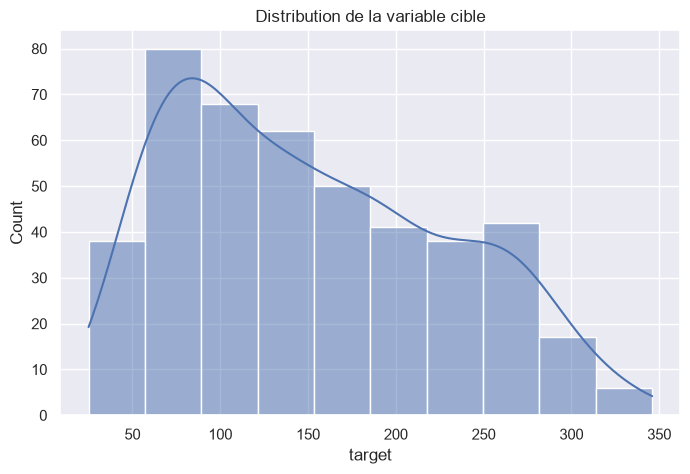

In [12]:
plt.figure(figsize=(8, 5))
sns.histplot(df["target"], kde=True)
plt.xlabel("target")
plt.title("Distribution de la variable cible")
plt.show()

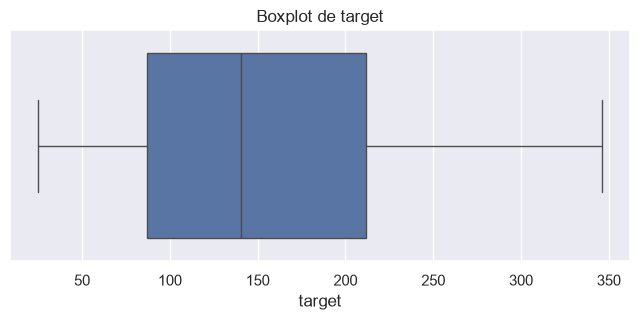

In [13]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=df["target"])
plt.title("Boxplot de target")
plt.show()

### Rappel — boxplot

Un boxplot permet notamment de visualiser :
- la médiane ;
- les quartiles ;
- la dispersion ;
- certaines observations extrêmes.

Une valeur extrême n'est pas nécessairement une erreur.

> **Il ne faut jamais supprimer automatiquement une observation simplement parce qu'elle est atypique.**

<Axes: ylabel='target'>

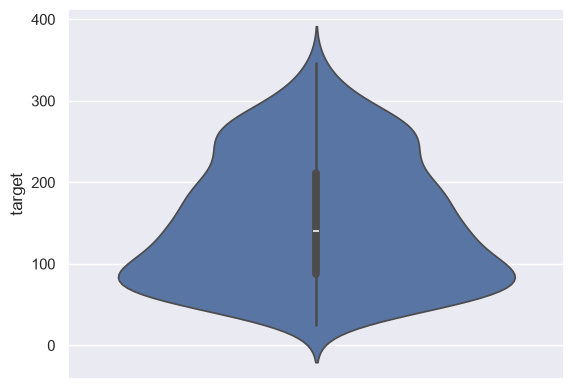

In [14]:
sns.violinplot(data=df["target"])

## 7. Distribution des variables explicatives

Regardons maintenant les variables explicatives.

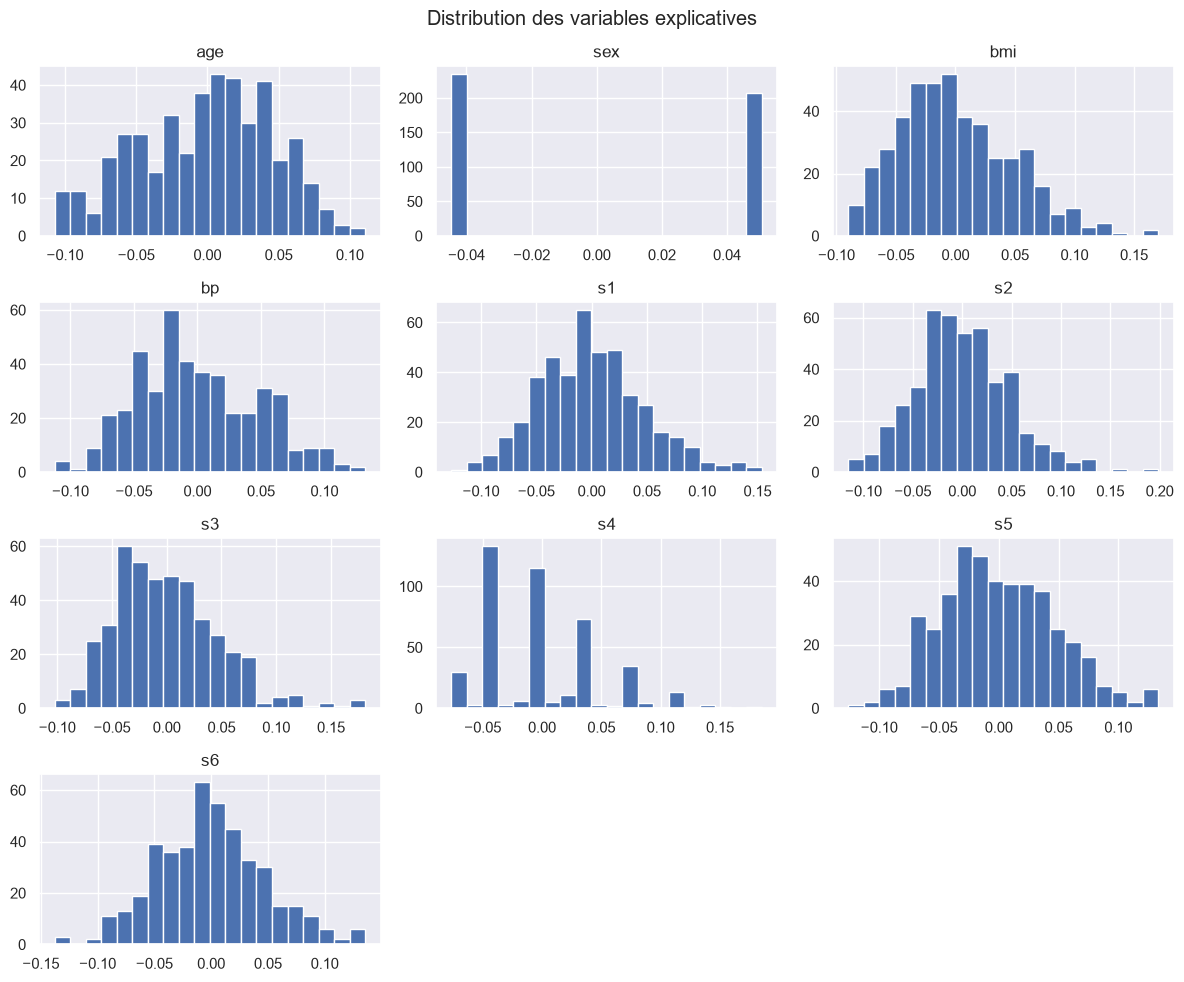

In [15]:
df.drop(columns="target").hist(
    figsize=(12, 10),
    bins=20
)

plt.suptitle("Distribution des variables explicatives")
plt.tight_layout()
plt.show()

### Une particularité du jeu Diabetes

Les variables explicatives de `load_diabetes()` ont été **centrées et mises à l'échelle**.

Cela explique pourquoi elles ont des valeurs assez petites.

C'est une situation particulière. Dans beaucoup de jeux de données réels, les variables peuvent avoir des unités et des échelles très différentes.

## 8. Les associations entre variables

Pour deux variables quantitatives, nous pouvons calculer leur corrélation.

La corrélation de Pearson est :

$
r_{XY}
=
\frac{Cov(X,Y)}
{\sigma_X\sigma_Y}
$

Elle est comprise entre -1 et 1.

- `r ≈ 1` : association linéaire positive forte ;
- `r ≈ -1` : association linéaire négative forte ;
- `r ≈ 0` : pas d'association linéaire importante.

⚠️ **Corrélation ne signifie pas causalité.**

In [16]:
correlations = df.corr()

correlations

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
age,1.000000,0.173737,0.185085,0.335428,0.260061,0.219243,-0.075181,0.203841,0.270774,0.301731,0.187889
sex,0.173737,1.000000,0.088161,0.241010,0.035277,0.142637,-0.379090,0.332115,0.149916,0.208133,0.043062
bmi,0.185085,0.088161,1.000000,0.395411,0.249777,0.261170,-0.366811,0.413807,0.446157,0.388680,0.586450
bp,0.335428,0.241010,0.395411,1.000000,0.242464,0.185548,-0.178762,0.257650,0.393480,0.390430,0.441482
s1,0.260061,0.035277,0.249777,0.242464,1.000000,0.896663,0.051519,0.542207,0.515503,0.325717,0.212022
s2,0.219243,0.142637,0.261170,0.185548,0.896663,1.000000,-0.196455,0.659817,0.318357,0.290600,0.174054
s3,-0.075181,-0.379090,-0.366811,-0.178762,0.051519,-0.196455,1.000000,-0.738493,-0.398577,-0.273697,-0.394789
s4,0.203841,0.332115,0.413807,0.257650,0.542207,0.659817,-0.738493,1.000000,0.617859,0.417212,0.430453
s5,0.270774,0.149916,0.446157,0.393480,0.515503,0.318357,-0.398577,0.617859,1.000000,0.464669,0.565883
s6,0.301731,0.208133,0.388680,0.390430,0.325717,0.290600,-0.273697,0.417212,0.464669,1.000000,0.382483


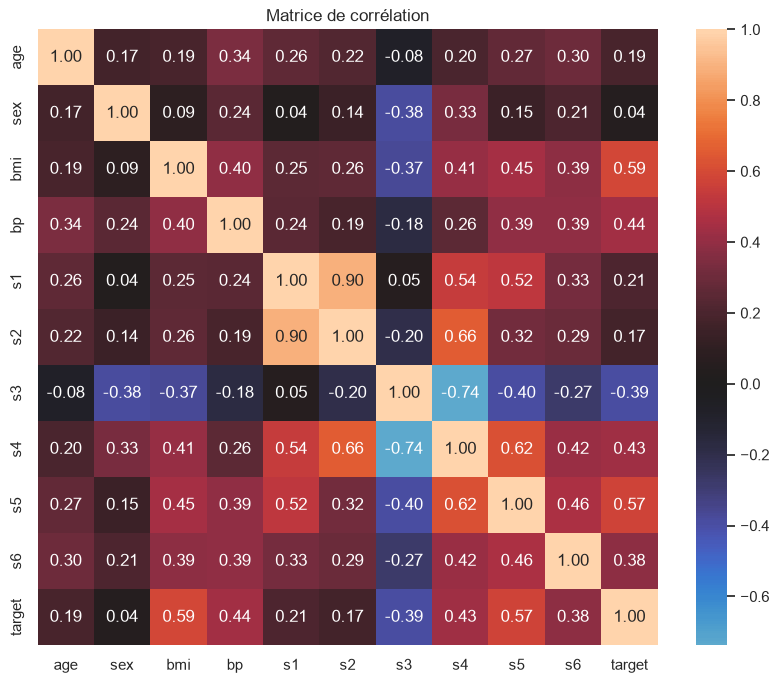

In [17]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlations,
    annot=True,
    fmt=".2f",
    center=0
)

plt.title("Matrice de corrélation")
plt.show()

In [18]:
correlations["target"].sort_values(ascending=False)

target    1.000000
bmi       0.586450
s5        0.565883
bp        0.441482
s4        0.430453
s6        0.382483
s1        0.212022
age       0.187889
s2        0.174054
sex       0.043062
s3       -0.394789
Name: target, dtype: float64

### Question d'interprétation

1. Quelle variable semble avoir l'association linéaire positive la plus forte avec `target` ?
2. Quelle variable semble avoir l'association négative la plus forte ?
3. Est-ce que la variable la plus corrélée explique nécessairement la majorité de la variabilité de `target` ?

## 9. Nuages de points

La corrélation donne un résumé numérique.

Le graphique permet de voir la relation directement.

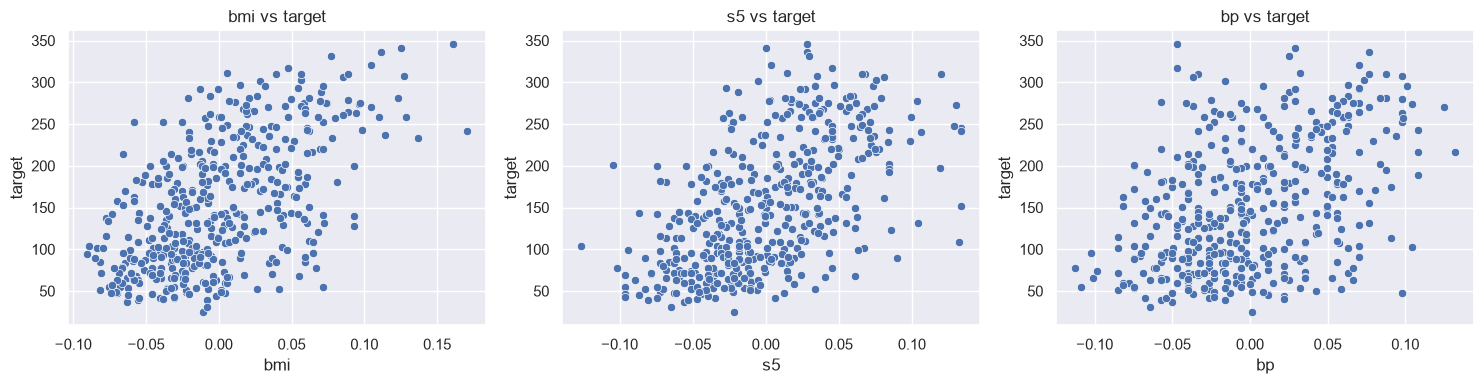

In [19]:
variables = ["bmi", "s5", "bp"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, variable in zip(axes, variables):
    sns.scatterplot(
        data=df,
        x=variable,
        y="target",
        ax=ax
    )
    ax.set_title(f"{variable} vs target")

plt.tight_layout()
plt.show()

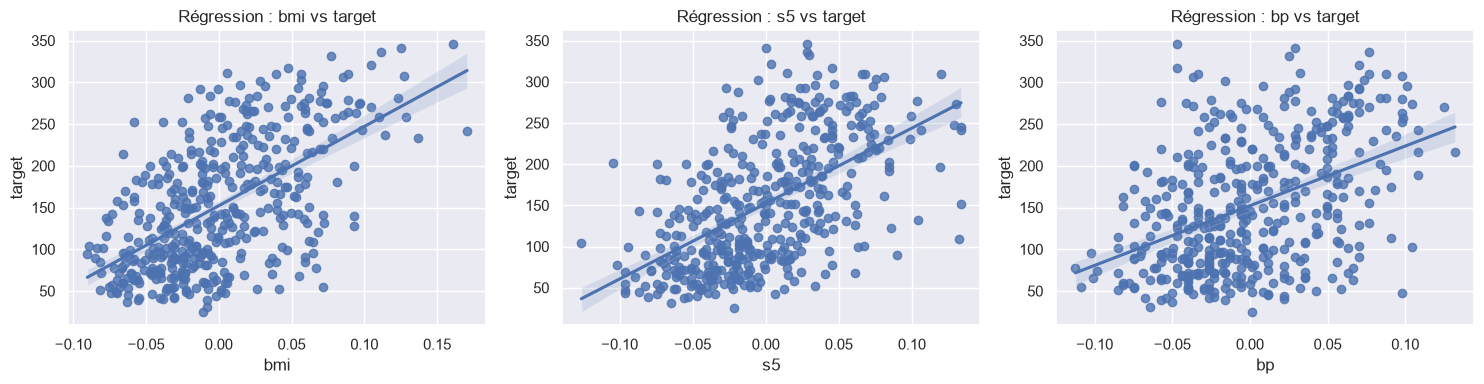

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, variable in zip(axes, variables):
    sns.regplot(
        data=df,
        x=variable,
        y="target",
        ax=ax
    )
    ax.set_title(f"Régression : {variable} vs target")

plt.tight_layout()
plt.show()

### Important

La droite représentée par `regplot` est une **droite descriptive**.

Nous n'avons pas encore construit notre modèle de régression multiple.

La prochaine séance consistera justement à formaliser cette idée.

## 10. Corrélation entre variables explicatives

Il faut aussi regarder si les variables explicatives sont elles-mêmes associées.

Cela sera important pour comprendre l'interprétation des coefficients d'une régression.

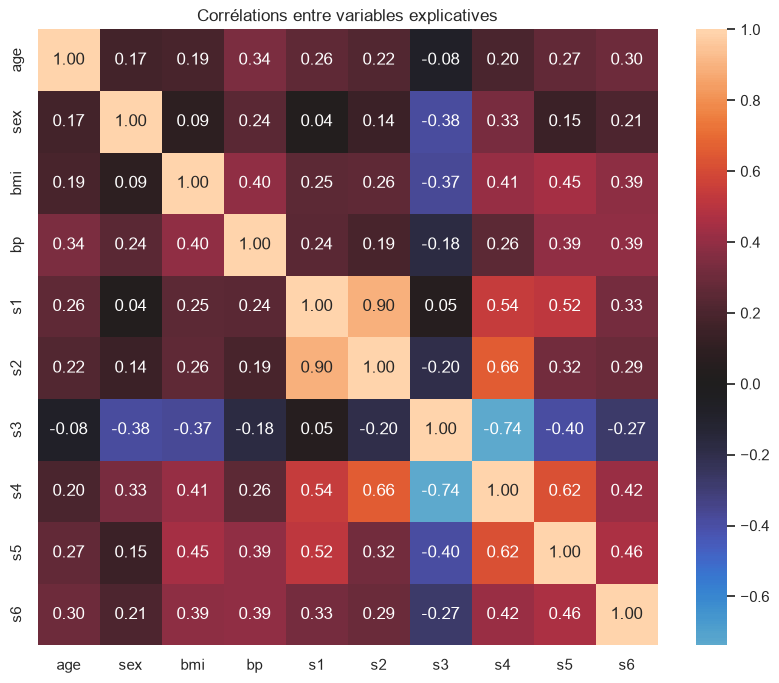

In [21]:
features = diabetes.feature_names

corr_features = df[features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_features,
    annot=True,
    fmt=".2f",
    center=0
)
plt.title("Corrélations entre variables explicatives")
plt.show()

### Question finale

Pourquoi peut-il être intéressant de connaître les associations entre **variables explicatives** avant de construire une régression ?

# Bilan de la séance

Nous avons appris à :

- charger un jeu de données ;
- construire un DataFrame ;
- distinguer `X` et `y` ;
- calculer des statistiques descriptives ;
- étudier les distributions ;
- vérifier les valeurs manquantes ;
- calculer et visualiser des corrélations ;
- étudier graphiquement les associations.

### À retenir

> **L'analyse statistique des données est une étape du Machine Learning, pas une étape facultative.**

La prochaine séance : **régression linéaire → coefficients → fonction de perte → R² → significativité statistique**.